In [1]:
import pandas as pd

DATA_PATH = "../data/processed/creditcard_features.csv"

df = pd.read_csv(DATA_PATH)

print("Feature dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Feature dataset loaded successfully!
Dataset Shape: (283726, 34)


In [2]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features (X) shape: (283726, 33)
Target (y) shape: (283726,)

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (226980, 33)
Testing set: (56746, 33)

Training target distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing target distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

ValueError: could not convert string to float: 'Afternoon'

In [5]:
X = pd.get_dummies(X, columns=["Time_Period"], drop_first=True)

print("Time_Period encoded successfully!")
print("New X shape:", X.shape)
print("Columns:")
print(X.columns.tolist())

Time_Period encoded successfully!
New X shape: (283726, 35)
Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'Log_Amount', 'Time_Period_Evening', 'Time_Period_Morning', 'Time_Period_Night']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("New training set:", X_train.shape)
print("New testing set:", X_test.shape)

New training set: (226980, 35)
New testing set: (56746, 35)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training shape: (226980, 35)
Scaled testing shape: (56746, 35)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Total predictions:", len(y_pred))
print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
Total predictions: 56746

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Model Evaluation Results
------------------------
Accuracy : 0.9991
Precision: 0.8308
Recall   : 0.5684
F1 Score : 0.675


In [1]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print("----------------")
print(cm)

NameError: name 'y_test' is not defined

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_PATH = "../data/processed/creditcard_features.csv"

df = pd.read_csv(DATA_PATH)

X = df.drop("Class", axis=1)
y = df["Class"]

X = pd.get_dummies(X, columns=["Time_Period"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation completed!")
print("Training:", X_train_scaled.shape)
print("Testing:", X_test_scaled.shape)

Data preparation completed!
Training: (226980, 35)
Testing: (56746, 35)


In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [4]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Total predictions:", len(y_pred))

Predictions generated successfully!
Total predictions: 56746


In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print("----------------")
print(cm)

Confusion Matrix
----------------
[[56640    11]
 [   41    54]]


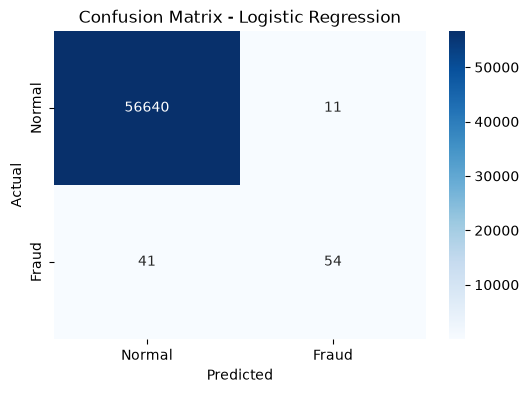

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [8]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [9]:
rf_y_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("Total predictions:", len(rf_y_pred))

Random Forest predictions generated successfully!
Total predictions: 56746


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

print("Random Forest Evaluation Results")
print("--------------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Evaluation Results
--------------------------------
Accuracy : 0.9995
Precision: 0.9718
Recall   : 0.7263
F1 Score : 0.8313
